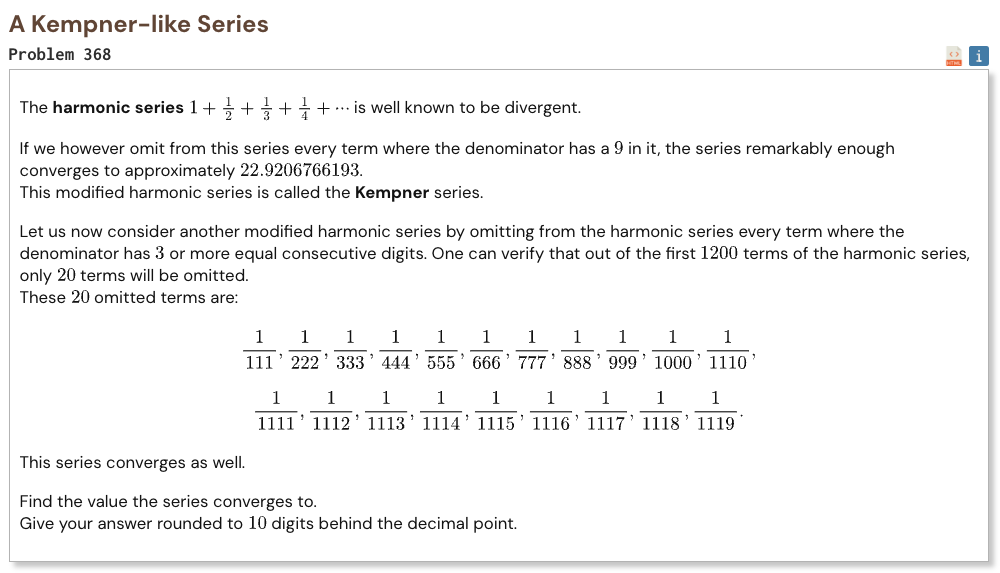

## Initial approach

* model allowed numbers by remembering the last digit and how long its current run is
* update the automaton one digit at a time
* instead of storing the actual numbers, store sums of inverse powers
* use a truncated series when appending a new digit
* keep enough inverse-power terms so the truncation error is tiny
* use numpy only to make the repeated vector updates fast
* stop after many digit lengths because the remaining tail is far below the needed precision

In [1]:
import math
import numpy as np

def transform_matrix(digit, power_count):
    matrix = np.zeros((power_count, power_count), dtype=np.float64)

    for p in range(1, power_count + 1):
        for m in range(power_count - p + 1):
            q = p + m
            coefficient = math.comb(p + m - 1, m)
            coefficient *= (-digit) ** m
            coefficient /= 10 ** (p + m)
            matrix[p - 1, q - 1] = coefficient

    return matrix

def solve():
    power_count = 35
    max_length = 6000

    transforms = [transform_matrix(d, power_count) for d in range(10)]

    states = np.zeros((10, 2, power_count), dtype=np.float64)

    for digit in range(1, 10):
        for p in range(1, power_count + 1):
            states[digit, 0, p - 1] = digit ** (-p)

    total = states[:, :, 0].sum()

    for _ in range(2, max_length + 1):
        next_states = np.zeros_like(states)

        for last_digit in range(10):
            for run in range(2):
                vector = states[last_digit, run]

                if vector[0] == 0.0:
                    continue

                for digit in range(10):
                    if digit == last_digit and run == 1:
                        continue

                    if digit == last_digit:
                        new_run = 1
                    else:
                        new_run = 0

                    next_states[digit, new_run] += transforms[digit] @ vector

        states = next_states
        total += states[:, :, 0].sum()

    return total

In [2]:
%%time
result = solve()
print("Result:", f"{result:.10f}")

Result: 255.1099162336
CPU times: user 1.34 s, sys: 26 ms, total: 1.37 s
Wall time: 1.35 s
